In [2]:
import pandas as pd

df=pd.read_csv(r"/Users/suriya/Ukesh_AIML_Projects/Content_Monetization_Modeler/Data/youtube_ad_revenue_dataset.csv")
df


,video_id,date,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,category,device,country,ad_revenue_usd
0,vid_3092,2024-09-24 10:50:40.993199,9936,1221.0,320.0,26497.214184,2.862137,228086,Entertainment,TV,IN,203.178237
1,vid_3459,2024-09-22 10:50:40.993199,10017,642.0,346.0,15209.747445,23.738069,736015,Gaming,Tablet,CA,140.880508
2,vid_4784,2024-11-21 10:50:40.993199,10097,1979.0,187.0,57332.658498,26.200634,240534,Education,TV,CA,360.134008
3,vid_4078,2025-01-28 10:50:40.993199,10034,1191.0,242.0,31334.517771,11.770340,434482,Entertainment,Mobile,UK,224.638261
4,vid_3522,2025-04-28 10:50:40.993199,9889,1858.0,477.0,15665.666434,6.635854,42030,Education,Mobile,CA,165.514388
...,...,...,...,...,...,...,...,...,...,...,...,...
122395,vid_2902,2024-12-14 10:50:40.993199,9853,1673.0,147.0,42075.704885,25.490195,210818,Education,Tablet,US,280.986396
122396,vid_3890,2024-07-13 10:50:40.993199,10128,1709.0,63.0,57563.703040,16.229133,878860,Music,Desktop,UK,354.612981
122397,vid_3934,2024-06-10 10:50:40.993199,10267,700.0,NaN,27549.714659,23.822365,576756,Tech,Tablet,CA,203.643106
122398,vid_4260,2024-12-22 10:50:40.993199,10240,1616.0,106.0,56967.384382,7.753099,585138,Music,Mobile,UK,351.525811


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122400 entries, 0 to 122399
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   video_id              122400 non-null  object 
 1   date                  122400 non-null  object 
 2   views                 122400 non-null  int64  
 3   likes                 116283 non-null  float64
 4   comments              116288 non-null  float64
 5   watch_time_minutes    116295 non-null  float64
 6   video_length_minutes  122400 non-null  float64
 7   subscribers           122400 non-null  int64  
 8   category              122400 non-null  object 
 9   device                122400 non-null  object 
 10  country               122400 non-null  object 
 11  ad_revenue_usd        122400 non-null  float64
dtypes: float64(5), int64(2), object(5)
memory usage: 11.2+ MB


In [4]:
df.duplicated().sum()

np.int64(2400)

In [5]:
df.drop_duplicates(inplace=True)

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.isnull().sum()

video_id                   0
date                       0
views                      0
likes                   6000
comments                6000
watch_time_minutes      6000
video_length_minutes       0
subscribers                0
category                   0
device                     0
country                    0
ad_revenue_usd             0
dtype: int64

In [36]:
(df.isnull().sum()/len(df))*100

video_id                0.0
date                    0.0
views                   0.0
likes                   5.0
comments                5.0
watch_time_minutes      5.0
video_length_minutes    0.0
subscribers             0.0
category                0.0
device                  0.0
country                 0.0
ad_revenue_usd          0.0
dtype: float64

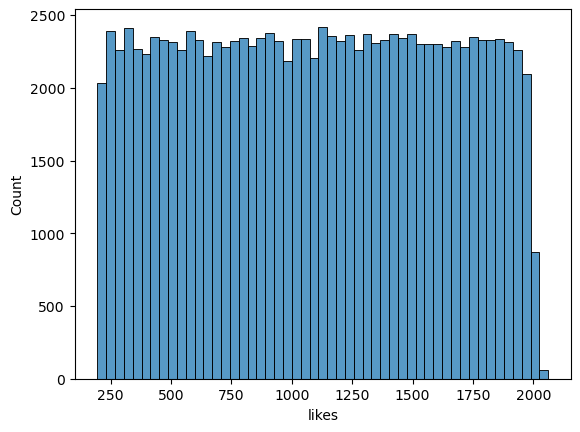

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['likes'])
plt.show()

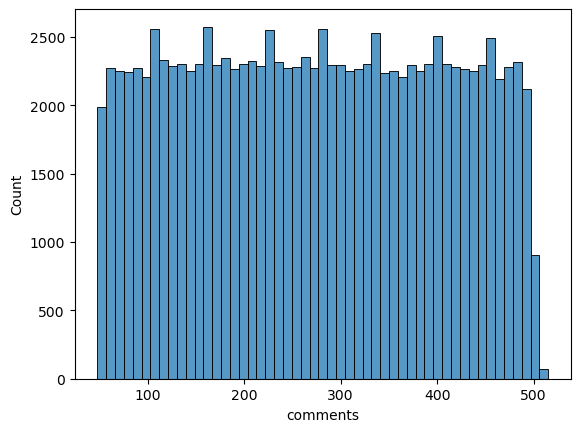

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['comments'])
plt.show()

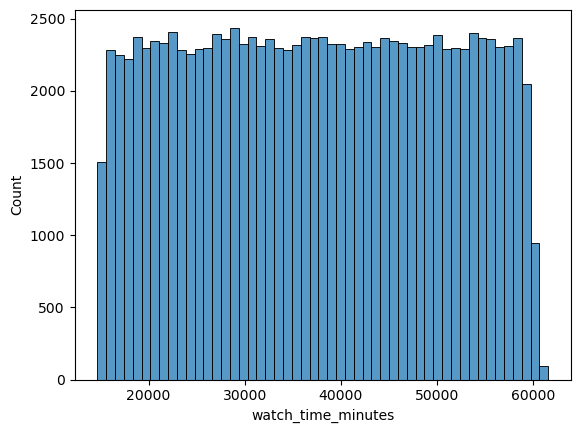

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['watch_time_minutes'])
plt.show()

In [40]:
print(df['likes'].skew())

-0.0022019491413401196


In [41]:
print(df["comments"].skew())

0.008230197889949997


In [42]:
print(df['watch_time_minutes'].skew())

0.0015307156917246784


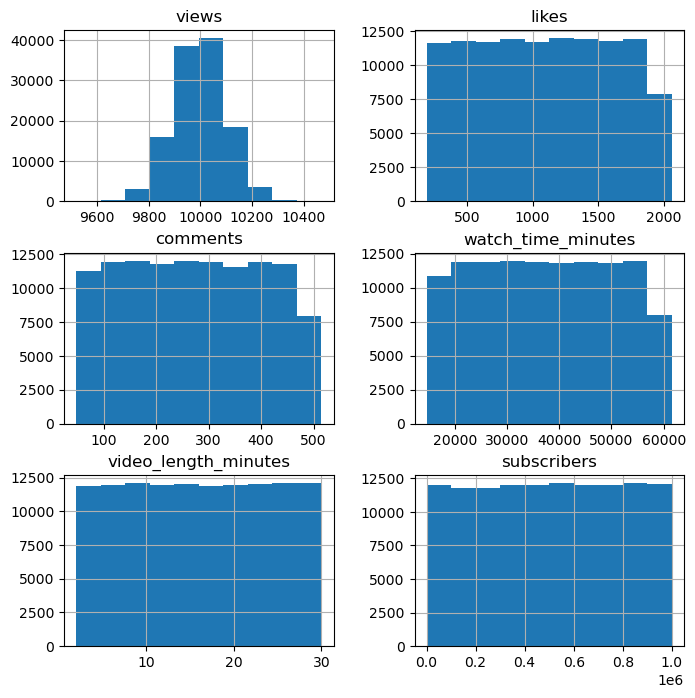

In [43]:
num_cols = ['views','likes','comments','watch_time_minutes','video_length_minutes','subscribers']

df[num_cols].hist(figsize=(8,8))
plt.show()

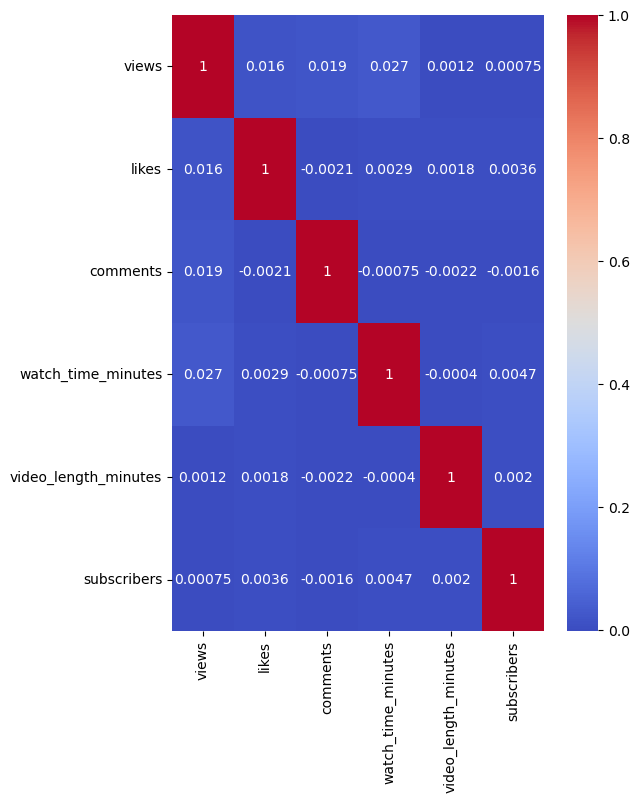

In [44]:
plt.figure(figsize=(6,8))

sns.heatmap(df[num_cols].corr(),annot=True,cmap='coolwarm')

plt.show()

In [8]:
corr_with_target = df.corr(numeric_only=True)['ad_revenue_usd'].sort_values(ascending=False)
print(corr_with_target)

ad_revenue_usd          1.000000
watch_time_minutes      0.988869
likes                   0.146269
views                   0.037942
comments                0.034494
subscribers             0.005065
video_length_minutes    0.000364
Name: ad_revenue_usd, dtype: float64


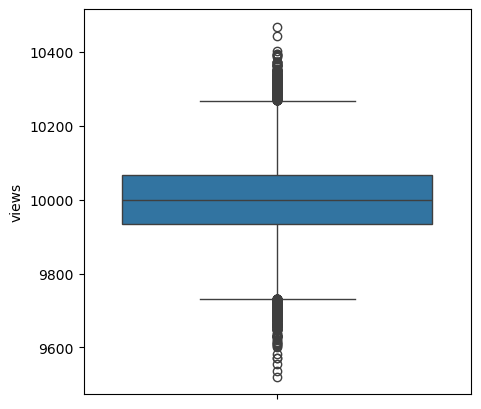

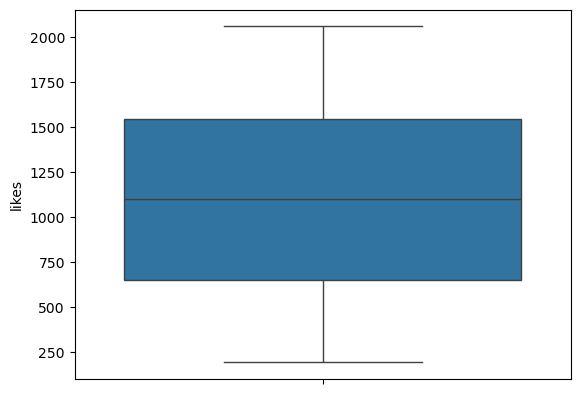

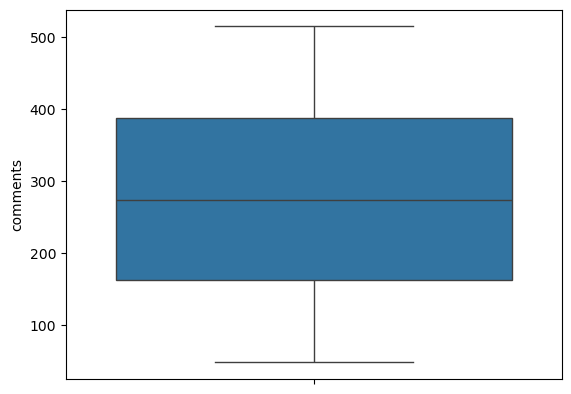

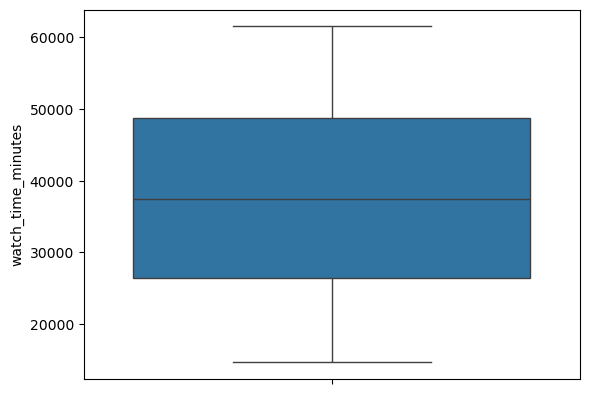

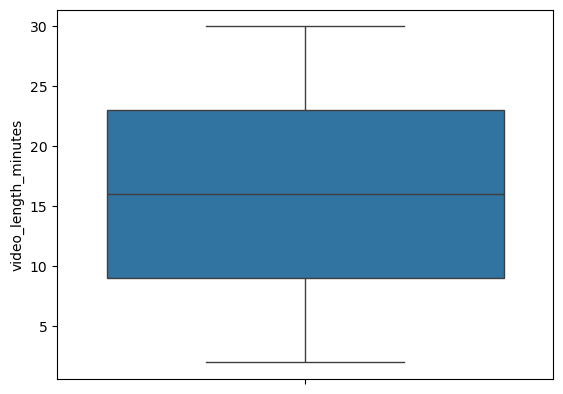

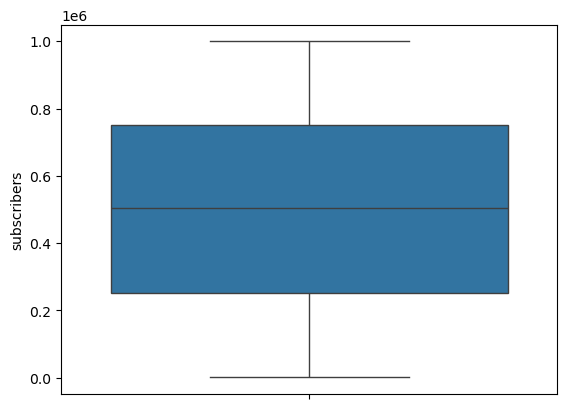

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = ['views','likes','comments','watch_time_minutes','video_length_minutes','subscribers']
plt.figure(figsize=(5,5))
for col in num_cols:
    sns.boxplot(df[col])
    plt.show()

## EDA Observation

## From the EDA process, I observed there are 2400 duplicate rows so i just drop duplicates and  there is some null values in columns(likes,comments,watch_time_minutes) but count of null values is minimal which is 5%. After performaing trend analysis and checking skew values i confirm that i am going to change the missing value with mean, bcs the data is symmetric for  likes, comments and watch_time_minutes columns there is no outliers percent, also skew values are nearly 0, so i go with mean replacing. Also i checked correlation for numerical columns, i obeserved that correlation values is nearly 0 for all, so i consider all columns are independent to each other.